In [60]:
import sqlite3
import pandas as pd

In [61]:
conn = sqlite3.connect("olist.db")

In [62]:
files = {
    "orders": "data/olist_orders_dataset.csv",
    "customers": "data/olist_customers_dataset.csv",
    "order_items": "data/olist_order_items_dataset.csv",
}

In [63]:
for table, path in files.items():
    df = pd.read_csv(path)
    df.to_sql(table, conn, if_exists="replace", index=False)
    print(f"{table}: {len(df):,} rows loaded")

orders: 99,441 rows loaded
customers: 99,441 rows loaded
order_items: 112,650 rows loaded


In [64]:
def run_query(query):
    return pd.read_sql_query(query, conn)


In [65]:
run_query("SELECT name FROM sqlite_master WHERE type = 'table';")

,name
0,orders
1,customers
2,order_items


In [66]:
import re

def load_queries(path="queries.sql"):
    with open(path, encoding="utf-8") as f:
        text = f.read()
    parts = re.split(r"^-- (Q\d+|TRAP):.*$", text, flags=re.MULTILINE)
    queries = {}
    for i in range(1, len(parts), 2):
        queries[parts[i]] = parts[i + 1].strip()
    return queries

queries = load_queries()

display(pd.read_sql(queries["TRAP"], conn))

,total_rows,unique_customer_id,unique_customer_unique_id
0,99441,99441,96096


In [67]:
# Q1
delivered = pd.read_sql(queries["Q1"], conn)
print(f"Delivered orders: {len(delivered):,}")
display(delivered.head())

Delivered orders: 96,478


,order_id,customer_unique_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39


In [68]:
# Q2
queries = load_queries()
display(pd.read_sql(queries["Q2"], conn))

,customer_unique_id,cohort_month
0,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09
1,0032c76b20340da25249092a268ce66c,2016-10
2,01f156677184504063bd19739f924af1,2016-10
3,0636d30c77f0f9cfad81f1c9b58c791f,2016-10
4,06bdfbbe1857c3c925ec81abfb1c9666,2016-10
...,...,...
93353,ffc39051848c3ef2be36d1513aa3ad17,2018-08
93354,ffc4e1cd8aa220763480d0a18157c45d,2018-08
93355,ffe204b1bb8026741b839085b2fd10f2,2018-08
93356,ffec490ab531184a483efe2eedd68908,2018-08


In [69]:
# Q3
queries = load_queries()
display(pd.read_sql(queries["Q3"], conn))

,customer_unique_id,order_id,order_month
0,830d5b7aaa3b6f1e9ad63703bec97d23,bfbd0f9bdef84302105ad712db648a6c,2016-09
1,12cc890391e57d7123e004856ff1f137,cbbb524a0e1646aa6cf7a3c0bbe517ad,2016-10
2,664f7107c351f24b16b68919398730a0,ac2b7c522d811acba0aa270ed3e112e4,2016-10
3,1dc848c11c2985635c268ff3dea707eb,7033745709b7cf1bac7d2533663592de,2016-10
4,fb48b86d9a78b53675c121e4ec8981ed,5cd498954e2b37d71b315166809b4bd7,2016-10
...,...,...,...
96473,2ed0ea186de34fab740cdb294d78701e,da95823b29f9ce7bcc4deebe1e568aff,2018-08
96474,531d6ca1ecce995a2317a0ca559e8c61,079c9f53e6c3253320db701a645b0b9a,2018-08
96475,8a898880a61e551c80bacadfb4356255,5597332b7eded552f104108f22b023e4,2018-08
96476,f690f0caffab80b6f849f08ba1692925,b3112ca67f3afd4e20cf2ee91fc4f804,2018-08


In [70]:
# Q4
queries = load_queries()
q4 = pd.read_sql(queries["Q4"], conn)
display(q4)


,customer_unique_id,order_id,cohort_month,order_month,period_number
0,830d5b7aaa3b6f1e9ad63703bec97d23,bfbd0f9bdef84302105ad712db648a6c,2016-09,2016-09,0
1,12cc890391e57d7123e004856ff1f137,cbbb524a0e1646aa6cf7a3c0bbe517ad,2016-10,2016-10,0
2,664f7107c351f24b16b68919398730a0,ac2b7c522d811acba0aa270ed3e112e4,2016-10,2016-10,0
3,1dc848c11c2985635c268ff3dea707eb,7033745709b7cf1bac7d2533663592de,2016-10,2016-10,0
4,fb48b86d9a78b53675c121e4ec8981ed,5cd498954e2b37d71b315166809b4bd7,2016-10,2016-10,0
...,...,...,...,...,...
96473,2ed0ea186de34fab740cdb294d78701e,da95823b29f9ce7bcc4deebe1e568aff,2018-08,2018-08,0
96474,531d6ca1ecce995a2317a0ca559e8c61,079c9f53e6c3253320db701a645b0b9a,2018-08,2018-08,0
96475,8a898880a61e551c80bacadfb4356255,5597332b7eded552f104108f22b023e4,2018-08,2018-08,0
96476,f690f0caffab80b6f849f08ba1692925,b3112ca67f3afd4e20cf2ee91fc4f804,2018-08,2018-08,0


In [71]:
print(f"period_number min: {q4['period_number'].min()}, max: {q4['period_number'].max()}")
print(f"Orders with period_number > 0: {(q4['period_number'] > 0).sum():,}")

period_number min: 0, max: 20
Orders with period_number > 0: 1,899


In [72]:
# Q5
queries = load_queries()
q5 = pd.read_sql(queries["Q5"], conn)
display(q5)

,cohort_month,p0,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11,p12,p13,p14,p15,p16,p17,p18,p19,p20
0,2016-09,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2016-10,262,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1,0,1,0,2,2
2,2016-12,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2017-01,717,2,2,1,3,1,3,1,1,0,3,1,5,3,1,1,2,3,0,1,0
4,2017-02,1628,3,5,2,7,2,4,3,2,3,2,5,2,3,2,1,1,3,0,0,0
5,2017-03,2503,11,9,10,9,4,4,8,8,2,9,3,5,3,4,6,2,3,0,0,0
6,2017-04,2256,14,5,4,6,6,8,7,7,4,6,2,1,1,2,2,3,0,0,0,0
7,2017-05,3451,16,16,10,10,11,14,5,9,9,9,12,8,1,6,7,0,0,0,0,0
8,2017-06,3037,15,12,13,9,12,11,7,4,6,9,11,5,5,7,0,0,0,0,0,0
9,2017-07,3752,20,13,9,11,8,12,4,7,10,8,11,5,9,0,0,0,0,0,0,0


In [73]:
# Q6
queries = load_queries()
q6 = pd.read_sql(queries["Q6"], conn)
display(q6)

,cohort_month,cohort_size
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,717
4,2017-02,1628
5,2017-03,2503
6,2017-04,2256
7,2017-05,3451
8,2017-06,3037
9,2017-07,3752


In [74]:
print(queries.keys())

dict_keys(['TRAP', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10'])


In [75]:
# Q7
pd.set_option("display.max_columns", None)
queries = load_queries()
q7 = pd.read_sql(queries["Q7"], conn)
display(q7)

,cohort_month,cohort_size,p0,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11,p12,p13,p14,p15,p16,p17,p18,p19,p20
0,2016-09,1,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
1,2016-10,262,100.0,0.00,0.00,0.00,0.00,0.00,0.38,0.00,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.0,0.76,0.76
2,2016-12,1,100.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
3,2017-01,717,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,0.00,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.0,0.14,NaN
4,2017-02,1628,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,0.0,NaN,NaN
5,2017-03,2503,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN,NaN,NaN
6,2017-04,2256,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,NaN,NaN,NaN,NaN
7,2017-05,3451,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23,0.03,0.17,0.20,NaN,NaN,NaN,NaN,NaN
8,2017-06,3037,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36,0.16,0.16,0.23,NaN,NaN,NaN,NaN,NaN,NaN
9,2017-07,3752,100.0,0.53,0.35,0.24,0.29,0.21,0.32,0.11,0.19,0.27,0.21,0.29,0.13,0.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
# Q8
queries = load_queries()
q8 = pd.read_sql(queries["Q8"], conn)
display(q8)

,period_number,n_cohorts,avg_retention_pct
0,0,20,100.00
1,1,19,0.48
2,2,18,0.34
3,3,17,0.25
4,4,16,0.29
5,5,15,0.23
6,6,14,0.26
7,7,13,0.21
8,8,12,0.21
9,9,11,0.16


In [77]:
# Q9
queries = load_queries()
q9 = pd.read_sql(queries["Q9"], conn)
display(q9)

,label,cohort_month,cohort_size,month1_customers,month1_retention_pct
0,best,2017-10,4328,31,0.72
1,worst,2017-02,1628,3,0.18


In [78]:
# Q10
queries = load_queries()
q10 = pd.read_sql(queries["Q10"], conn)
display(q10)

,cohort_month,period_number,revenue
0,2016-09,0,134.97
1,2016-10,0,40325.11
2,2016-10,6,99.99
3,2016-10,9,339.00
4,2016-10,11,49.00
...,...,...,...
214,2018-06,1,2425.72
215,2018-06,2,1584.98
216,2018-07,0,847944.56
217,2018-07,1,3702.87


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

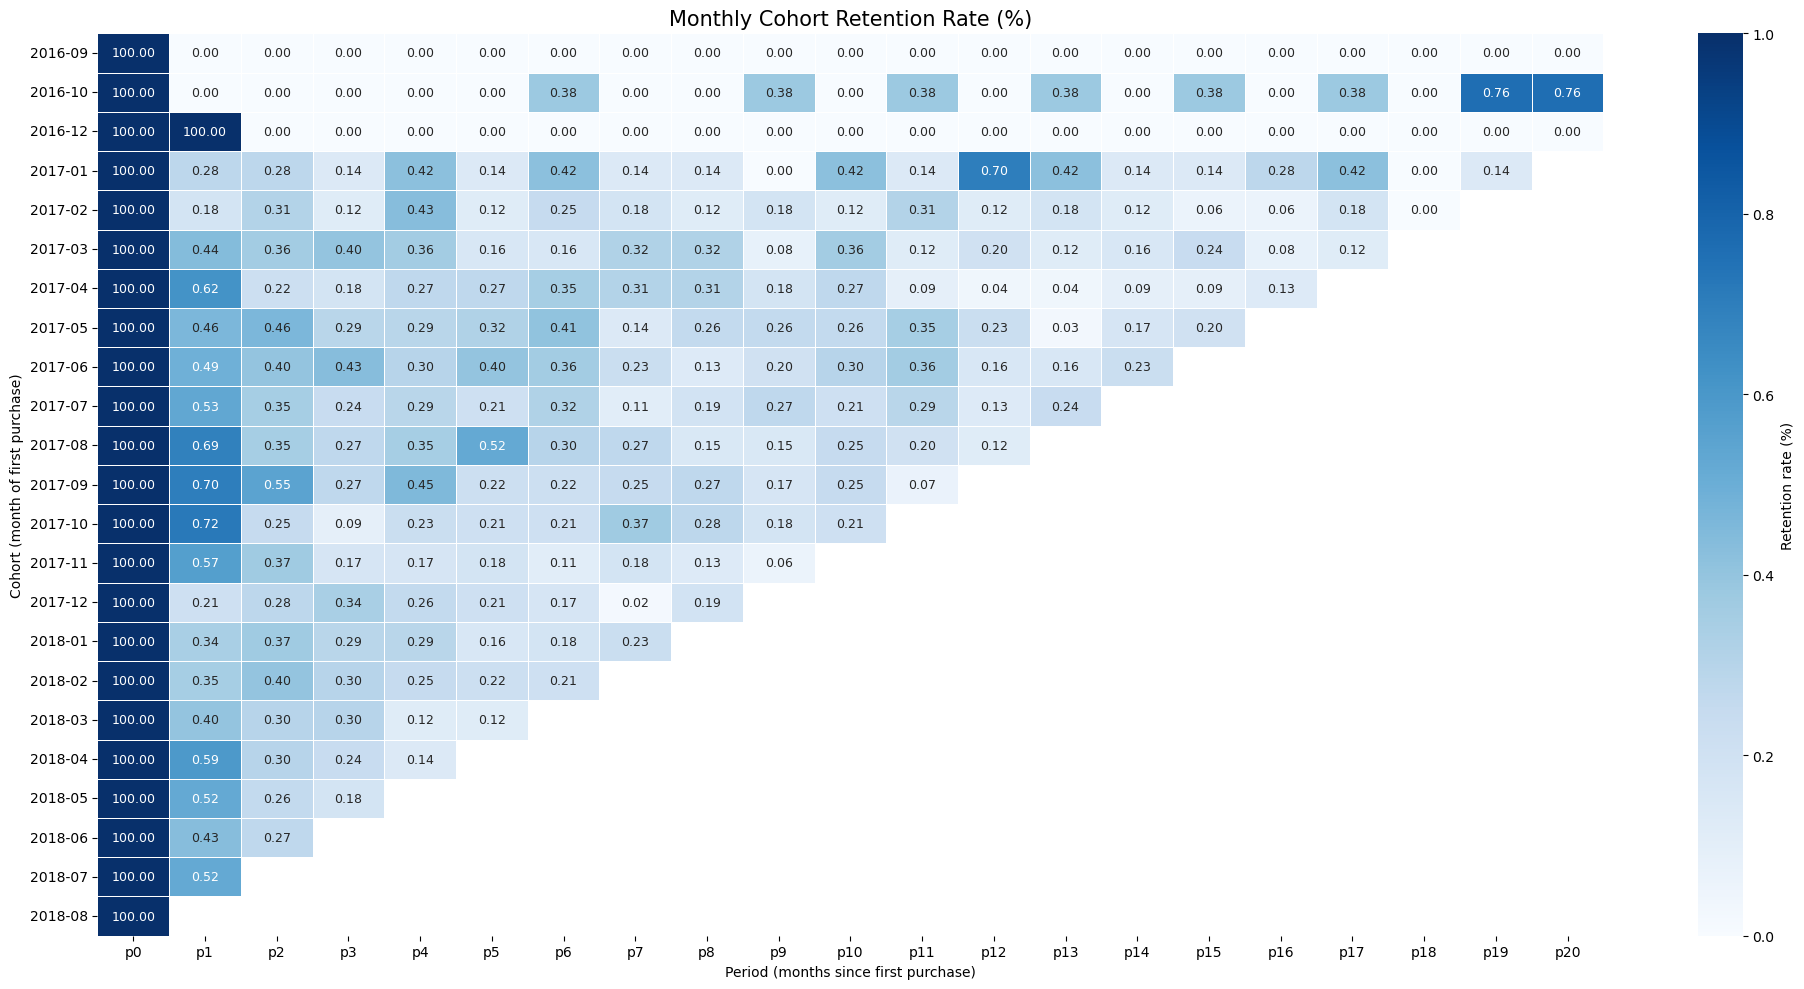

In [80]:
# Retention Heatmap
retention = q7.set_index("cohort_month").drop(columns="cohort_size")

plt.figure(figsize=(20, 10))
sns.heatmap(
    retention,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    annot_kws={"size": 9},
    linewidths=0.7,
    cbar_kws={"label": "Retention rate (%)"}
)
plt.title("Monthly Cohort Retention Rate (%)", fontsize=15)
plt.xlabel("Period (months since first purchase)")
plt.ylabel("Cohort (month of first purchase)")
plt.tight_layout()
plt.savefig("images/retention_heatmap.png", dpi=150)
plt.show()

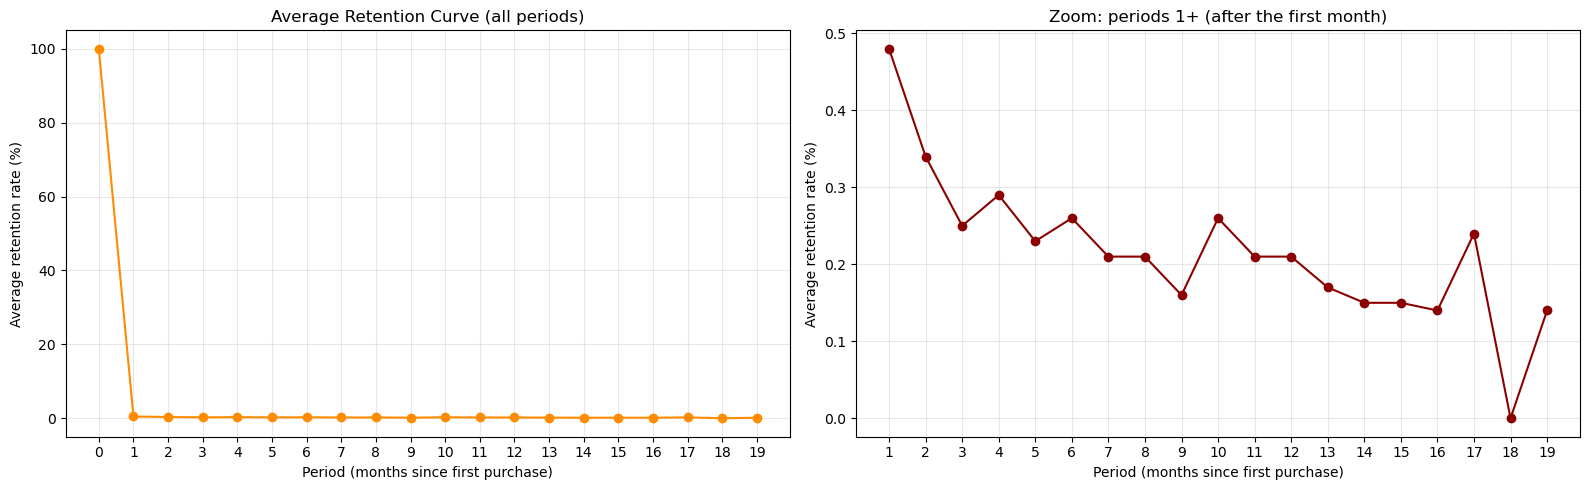

In [81]:
# Average retention curve
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left
axes[0].plot(q8["period_number"], q8["avg_retention_pct"], marker="o", color="darkorange")
axes[0].set_title("Average Retention Curve (all periods)")
axes[0].set_xlabel("Period (months since first purchase)")
axes[0].set_ylabel("Average retention rate (%)")
axes[0].set_xticks(q8["period_number"])
axes[0].grid(alpha=0.3)

# Right
zoom = q8[q8["period_number"] >= 1]
axes[1].plot(zoom["period_number"], zoom["avg_retention_pct"], marker="o", color="darkred")
axes[1].set_title("Zoom: periods 1+ (after the first month)")
axes[1].set_xlabel("Period (months since first purchase)")
axes[1].set_ylabel("Average retention rate (%)")
axes[1].set_xticks(zoom["period_number"])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("images/retention_curve.png", dpi=150)
plt.show()

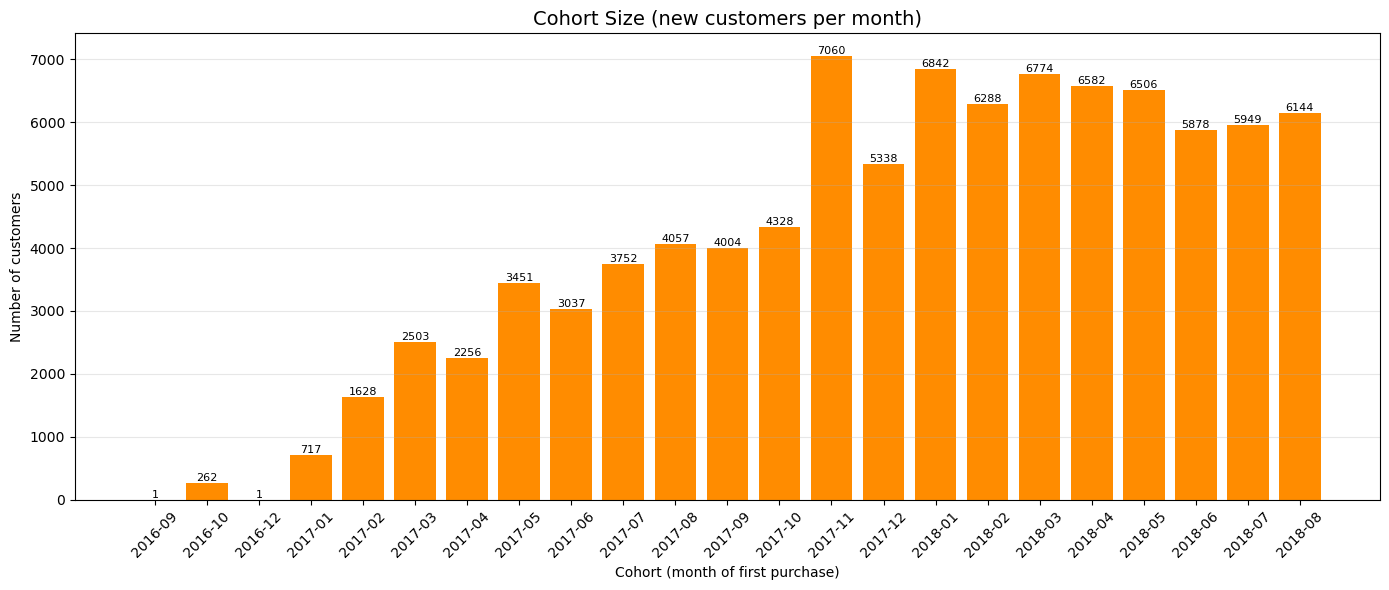

In [82]:
# Cohort size bar chart 
plt.figure(figsize=(14, 6))
bars = plt.bar(q6["cohort_month"], q6["cohort_size"], color="darkorange")
plt.bar_label(bars, fontsize=8)
plt.title("Cohort Size (new customers per month)", fontsize=14)
plt.xlabel("Cohort (month of first purchase)")
plt.ylabel("Number of customers")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("images/cohort_size.png", dpi=150)
plt.show()

Centre of the colour scale: 0.26%


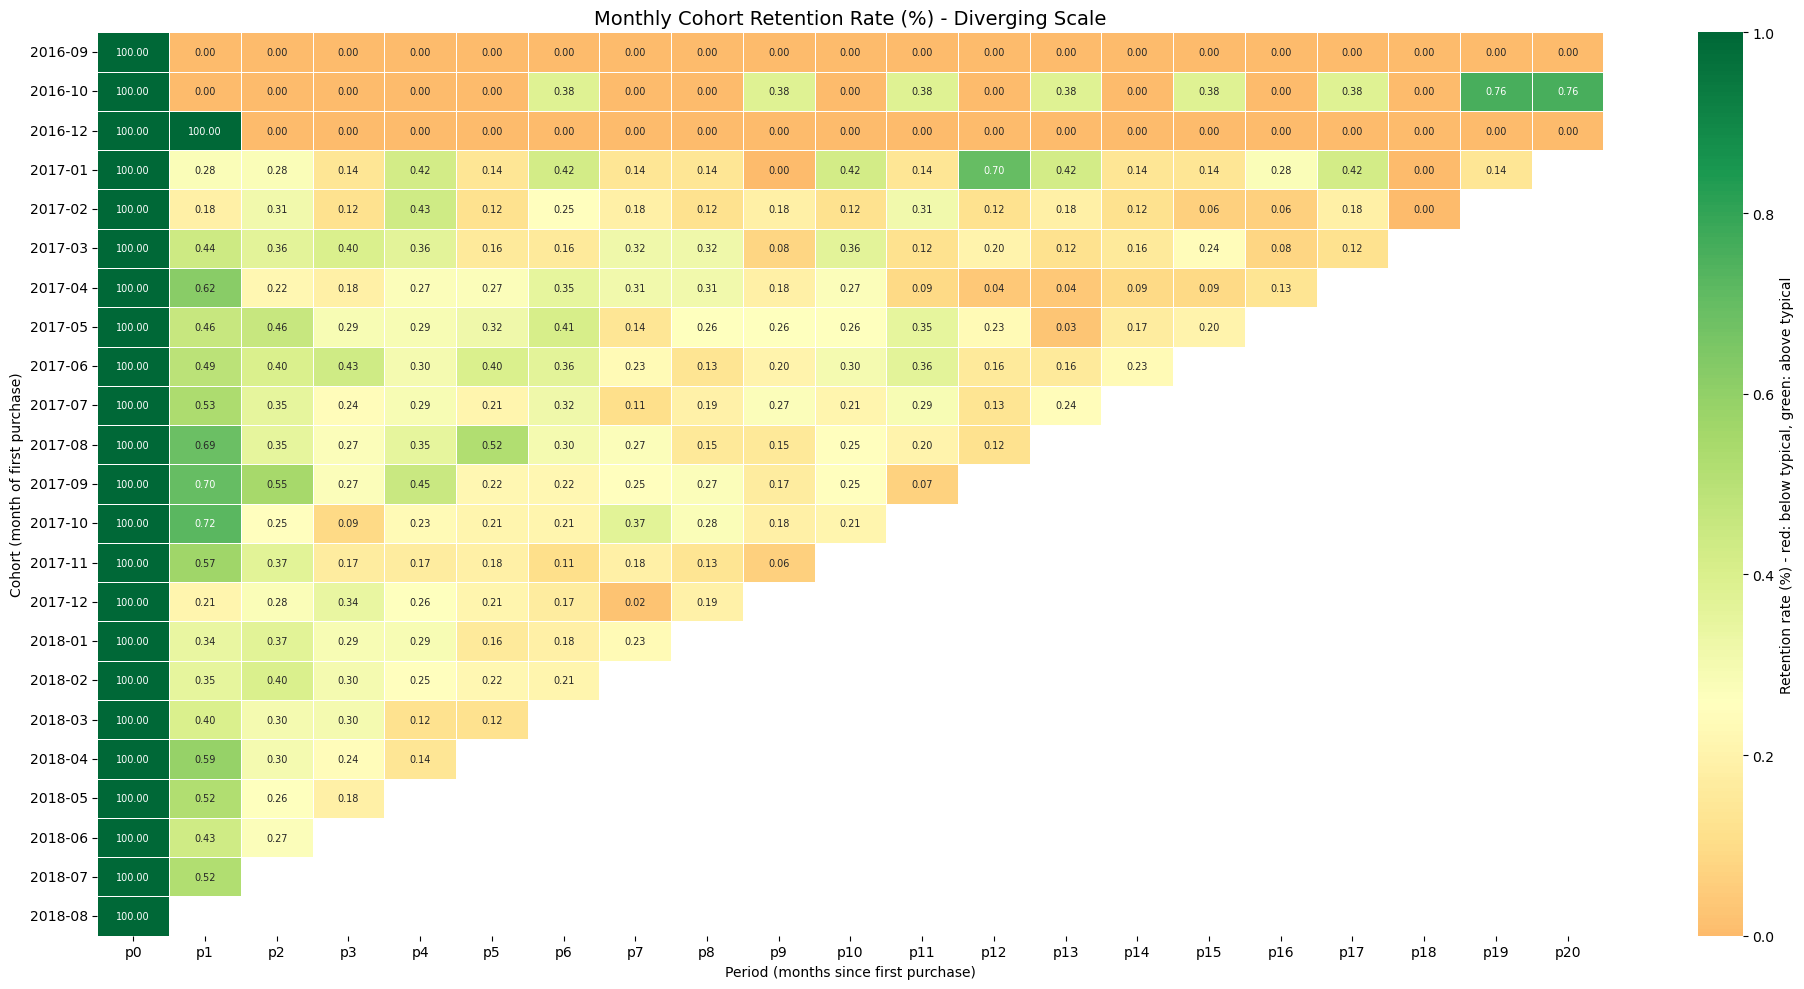

In [83]:
# Bonus: retention heatmap with a diverging colour scale
center_value = retention.loc["2017-01":].drop(columns="p0").stack().mean()
print(f"Centre of the colour scale: {center_value:.2f}%")

plt.figure(figsize=(20, 10))
sns.heatmap(
    retention,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=center_value,
    vmin=0,
    vmax=1,
    annot_kws={"size": 7},
    linewidths=0.5,
    cbar_kws={"label": "Retention rate (%) - red: below typical, green: above typical"}
)
plt.title("Monthly Cohort Retention Rate (%) - Diverging Scale", fontsize=14)
plt.xlabel("Period (months since first purchase)")
plt.ylabel("Cohort (month of first purchase)")
plt.tight_layout()
plt.savefig("images/retention_heatmap_diverging.png", dpi=150)
plt.show()